In [56]:
import math
import os
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks

In [57]:
USER = ['shuyuan', 'yizhou', 'kaiwen'] ## kaiwen or tianshu
USERCOLOR = ['red', 'blue', 'green']
ROTAXIS = ['roll', 'pitch', 'yaw'] ## yaw, pitch, roll
DIAMETER = 50 ## 50 or 80
LINESTYLES = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3,1,1,1,1,1))]
MARKERSTYLES = ['o', 's', 'D', '^', 'v']
TOTALTRIALS = 5
data_dir_dict = {}
pca_dict = {}
PCACOMPONENTS = ['components', 'variance', 'variance_ratio']
PCAFEATURES = [
    "Thumb Grav","Index Grav","Ring Grav",
    "Thumb Lateral","Index Lateral","Ring Lateral",
    "Thumb Normal","Ring Normal","Index Normal"
]
PCAORDER = [0,6,3,1,7,4,2,5,8]
PCADIM = len(PCAFEATURES)
for rot in ROTAXIS:
    data_dir_dict[rot]  = {}
    pca_dict[rot] = {}
    for usrs in USER:
        data_dir_dict[rot][usrs] = [f'data/segmented_data/{DIAMETER}mm/{usrs}/{rot}/test_{i}.csv' for i in range(1, TOTALTRIALS+1)]
        pca_dict[rot][usrs] = {}
        for pca_comp in PCACOMPONENTS:
            pca_dict[rot][usrs][pca_comp] = []

# Function Libs

In [58]:
def quick_visualization(data):

    max_val = np.max(data)
    min_val = np.min(data)

    up_bound = max_val * 1.2
    low_bound = min_val * 1.2

    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(311)
    ax1.plot(data[:, 0])
    ax1.plot(data[:, 1])
    ax1.plot(data[:, 2])
    ax1.set_title(f'Force Data - Thumb')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Force (N)')
    ax1.legend(['Fx', 'Fy', 'Fz'])
    ax1.set_ylim(low_bound, up_bound)

    ax2 = fig.add_subplot(312)
    ax2.plot(data[:, 3])
    ax2.plot(data[:, 4])
    ax2.plot(data[:, 5])
    ax2.set_title(f'Force Data - Ring')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Force (N)')
    ax2.legend(['Fx', 'Fy', 'Fz'])
    ax2.set_ylim(low_bound, up_bound)

    ax3 = fig.add_subplot(313)
    ax3.plot(data[:, 6])
    ax3.plot(data[:, 7])
    ax3.plot(data[:, 8])
    ax3.set_title(f'Force Data - Index')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('Force (N)')
    ax3.legend(['Fx', 'Fy', 'Fz'])
    ax3.set_ylim(low_bound, up_bound)
    
    plt.tight_layout()
    plt.show()

In [59]:
def load_data(data_dir_lis, visualize = False):
    data_lis_arr = []
    for file_dir in data_dir_lis:
        data = pd.read_csv(file_dir, header=None).to_numpy().reshape(-1,9)
        if visualize:
            quick_visualization(data)
        data_lis_arr.append(data)
    
    return data_lis_arr

In [60]:
def pca_analysis(data, n_components=PCADIM):
    pca = PCA(n_components=n_components)
    pca.fit_transform(data)
    return pca.components_, pca.explained_variance_, pca.explained_variance_ratio_

In [61]:
def data_process(data_dir_dict, pca_dict, visualize_flag=False):
    for rot in ROTAXIS:
        for usrs in USER:
            data_lis = data_dir_dict[rot][usrs]
            data_lis_arr = load_data(data_lis, visualize=visualize_flag)
            for data in data_lis_arr:
                components, variance, variance_ratio = pca_analysis(data)
                pca_dict[rot][usrs]['components'].append(components)
                pca_dict[rot][usrs]['variance'].append(variance)
                pca_dict[rot][usrs]['variance_ratio'].append(variance_ratio)
    return

In [62]:
def pca_data_analysis(pca_dict):
    for rot in ROTAXIS:
        for usrs in USER:
            print(f'User: {usrs.capitalize()}, Rotation Axis: {rot.capitalize()}')
            ratio_dict = {}
            for i in range(PCADIM):
                ratio_dict[i] = []

            for i in range(PCADIM):
                for j in range(TOTALTRIALS):
                    ratio = pca_dict[rot][usrs]['variance_ratio'][j][i]
                    ratio_dict[i].append(ratio)

            for i in range(PCADIM):
                mean_ratio = np.mean(ratio_dict[i])
                std_ratio = np.std(ratio_dict[i])
                print(f'PC{i+1}: {mean_ratio:.2%} ± {std_ratio:.2%}')

    return

In [63]:
def data_plotting(pca_dict):
    for rot in ROTAXIS:
        figure, axes = plt.subplots(PCADIM, 1, figsize=(12, 3 * PCADIM))
        for ax in axes:
            ax.set_ylim(-1, 1)
            ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
        for z,usrs in enumerate(USER):
            user_num = z + 1
            for i in range(TOTALTRIALS):
                components = pca_dict[rot][usrs]['components'][i]
                variance = pca_dict[rot][usrs]['variance'][i]
                variance_ratio = pca_dict[rot][usrs]['variance_ratio'][i]
                components_new = components[:, PCAORDER]
                # components_new = abs(components[:, PCAORDER])
                for j in range(components.shape[0]):
                    axes[j].plot(components_new[j], label=f'User {user_num}' if i==0 else None, color=USERCOLOR[z], linestyle=LINESTYLES[i])
                    axes[j].scatter(range(PCADIM), components_new[j], color=USERCOLOR[z], marker=MARKERSTYLES[i], s=20, edgecolors='black', zorder=5)
                    axes[j].set_xticks(range(PCADIM))
                    axes[j].set_xticklabels(PCAFEATURES)
                    if z == len(USER) - 1:
                        axes[j].set_ylabel(f'PC{j+1}')
                        if j == 0:
                            axes[j].set_title(f'{rot.capitalize()}')
                    axes[j].legend()
    return

# Analysis

In [64]:
data_process(data_dir_dict, pca_dict, False)

In [65]:
pca_data_analysis(pca_dict)

User: Shuyuan, Rotation Axis: Roll
PC1: 62.85% ± 5.30%
PC2: 18.44% ± 1.19%
PC3: 8.83% ± 2.77%
PC4: 5.19% ± 1.25%
PC5: 2.18% ± 0.27%
PC6: 1.38% ± 0.23%
PC7: 0.68% ± 0.20%
PC8: 0.35% ± 0.04%
PC9: 0.10% ± 0.04%
User: Yizhou, Rotation Axis: Roll
PC1: 67.00% ± 5.94%
PC2: 16.66% ± 2.61%
PC3: 9.00% ± 2.45%
PC4: 3.61% ± 1.15%
PC5: 2.07% ± 0.88%
PC6: 1.01% ± 0.31%
PC7: 0.35% ± 0.15%
PC8: 0.23% ± 0.05%
PC9: 0.08% ± 0.02%
User: Kaiwen, Rotation Axis: Roll
PC1: 53.19% ± 5.48%
PC2: 21.87% ± 2.70%
PC3: 13.17% ± 2.33%
PC4: 6.68% ± 1.36%
PC5: 2.42% ± 0.34%
PC6: 1.66% ± 0.41%
PC7: 0.58% ± 0.06%
PC8: 0.35% ± 0.05%
PC9: 0.08% ± 0.04%
User: Shuyuan, Rotation Axis: Pitch
PC1: 59.31% ± 6.47%
PC2: 22.99% ± 5.03%
PC3: 9.58% ± 2.42%
PC4: 4.62% ± 0.78%
PC5: 2.36% ± 0.55%
PC6: 0.50% ± 0.11%
PC7: 0.34% ± 0.08%
PC8: 0.23% ± 0.06%
PC9: 0.06% ± 0.01%
User: Yizhou, Rotation Axis: Pitch
PC1: 71.11% ± 3.28%
PC2: 14.63% ± 2.67%
PC3: 7.84% ± 2.26%
PC4: 3.57% ± 0.34%
PC5: 1.68% ± 0.48%
PC6: 0.49% ± 0.05%
PC7: 0.37% ± 0.07

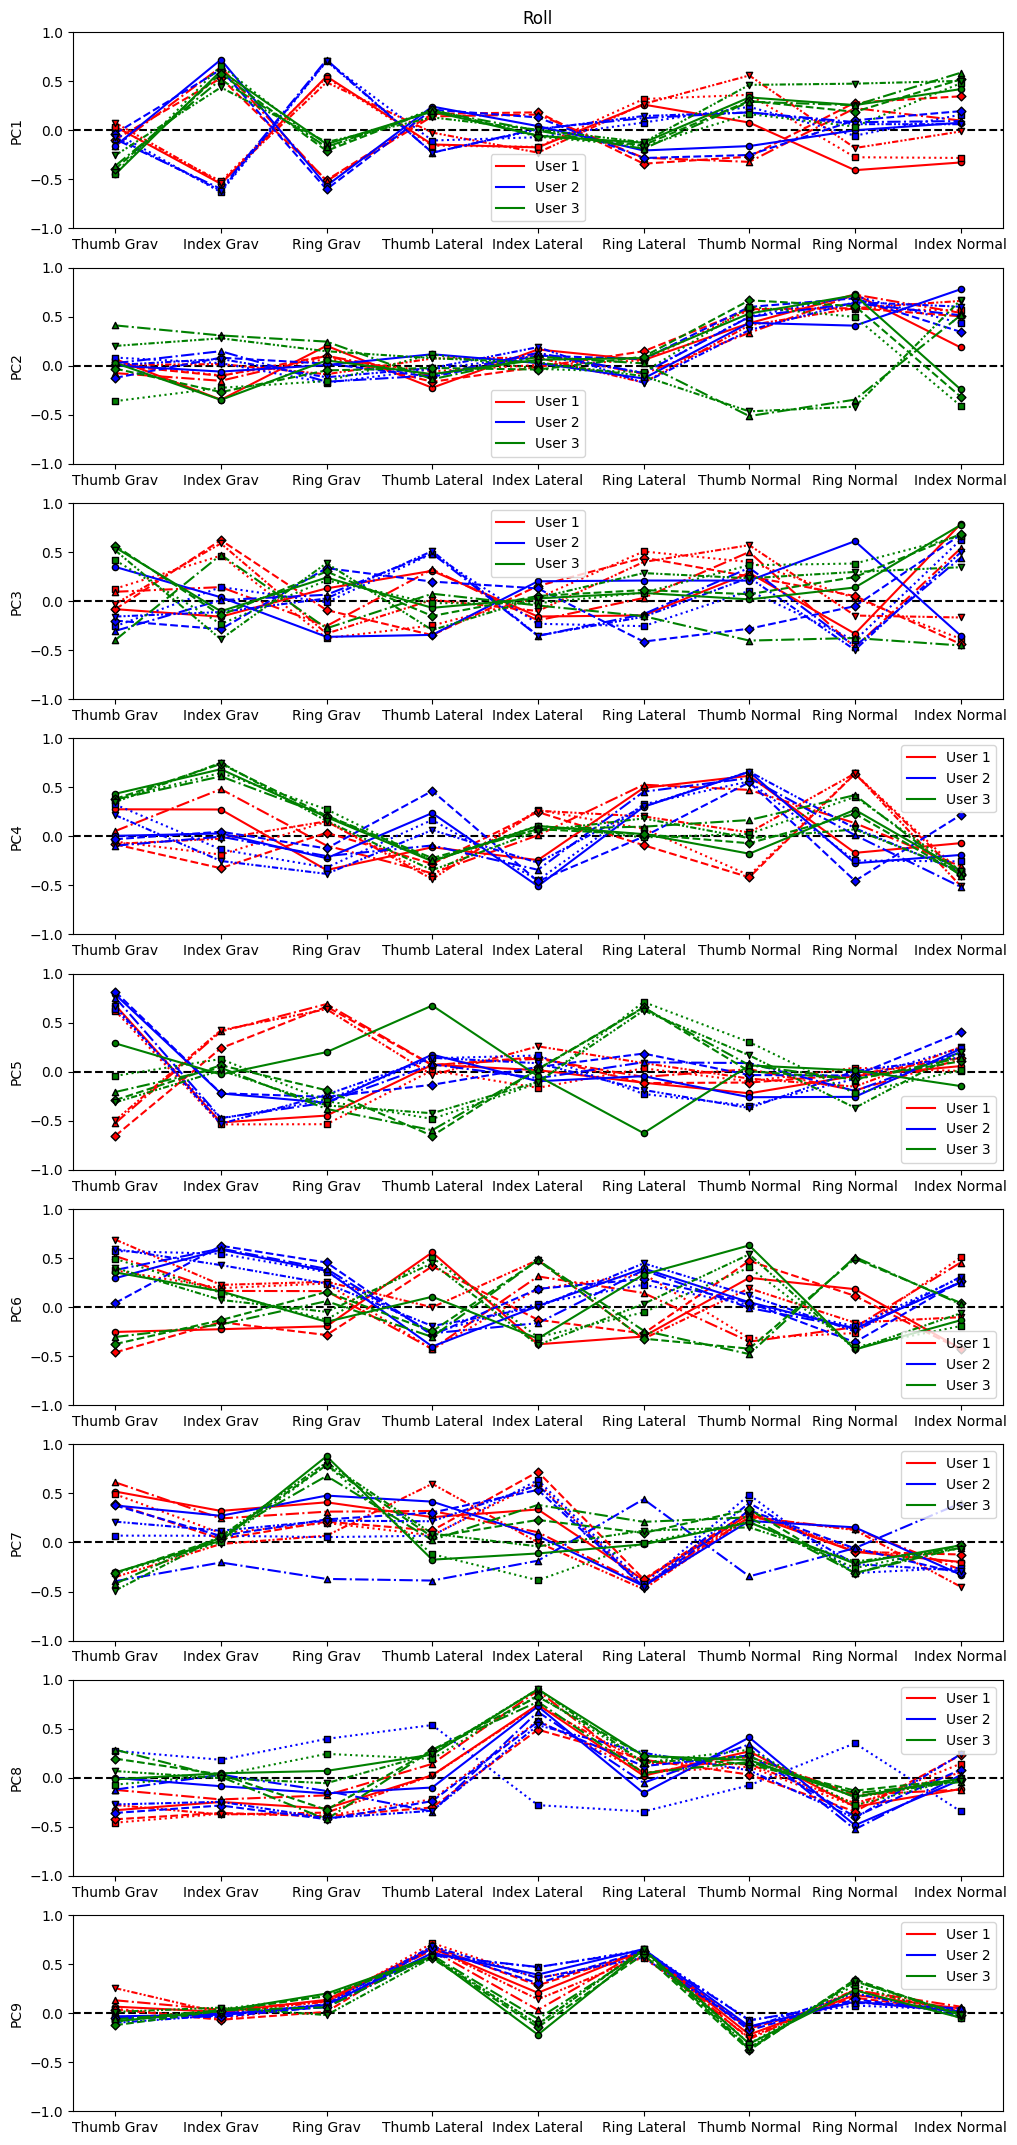

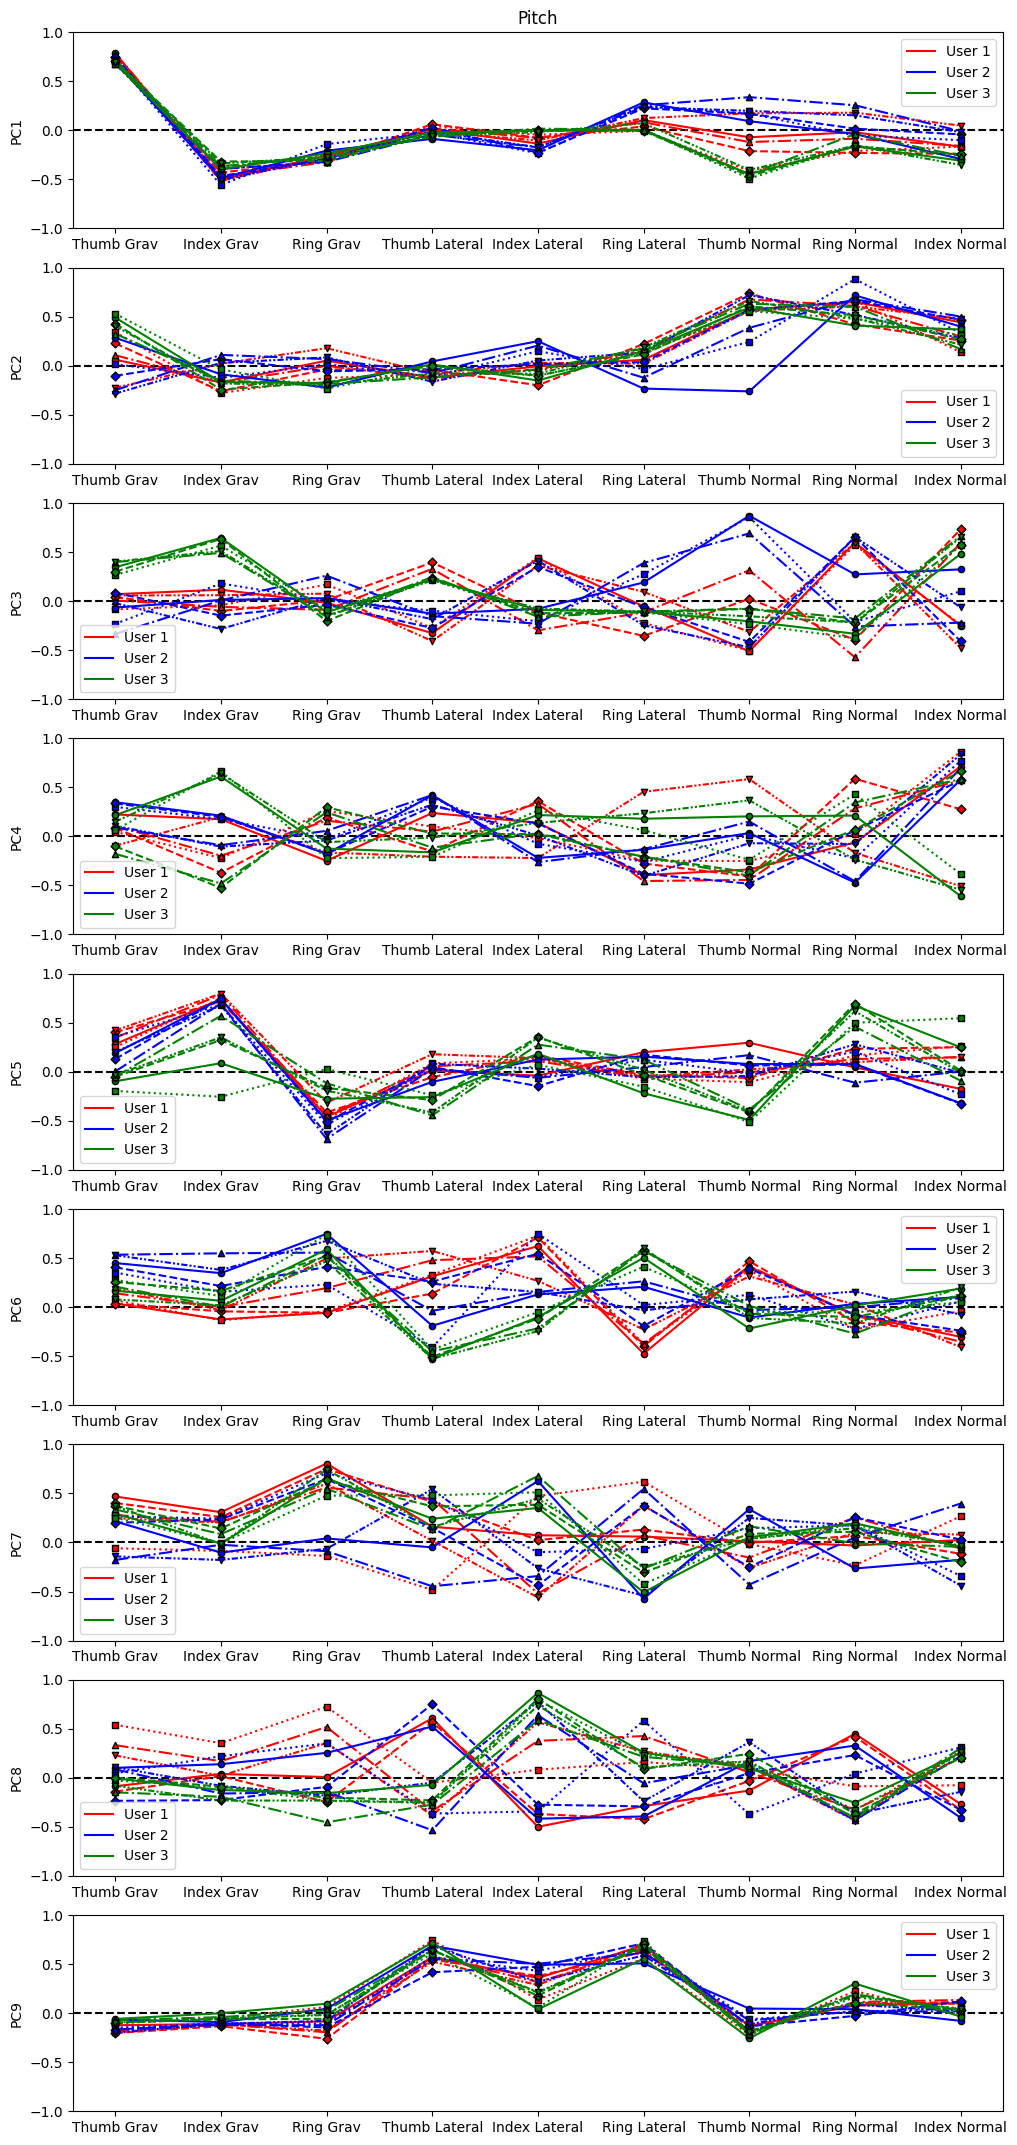

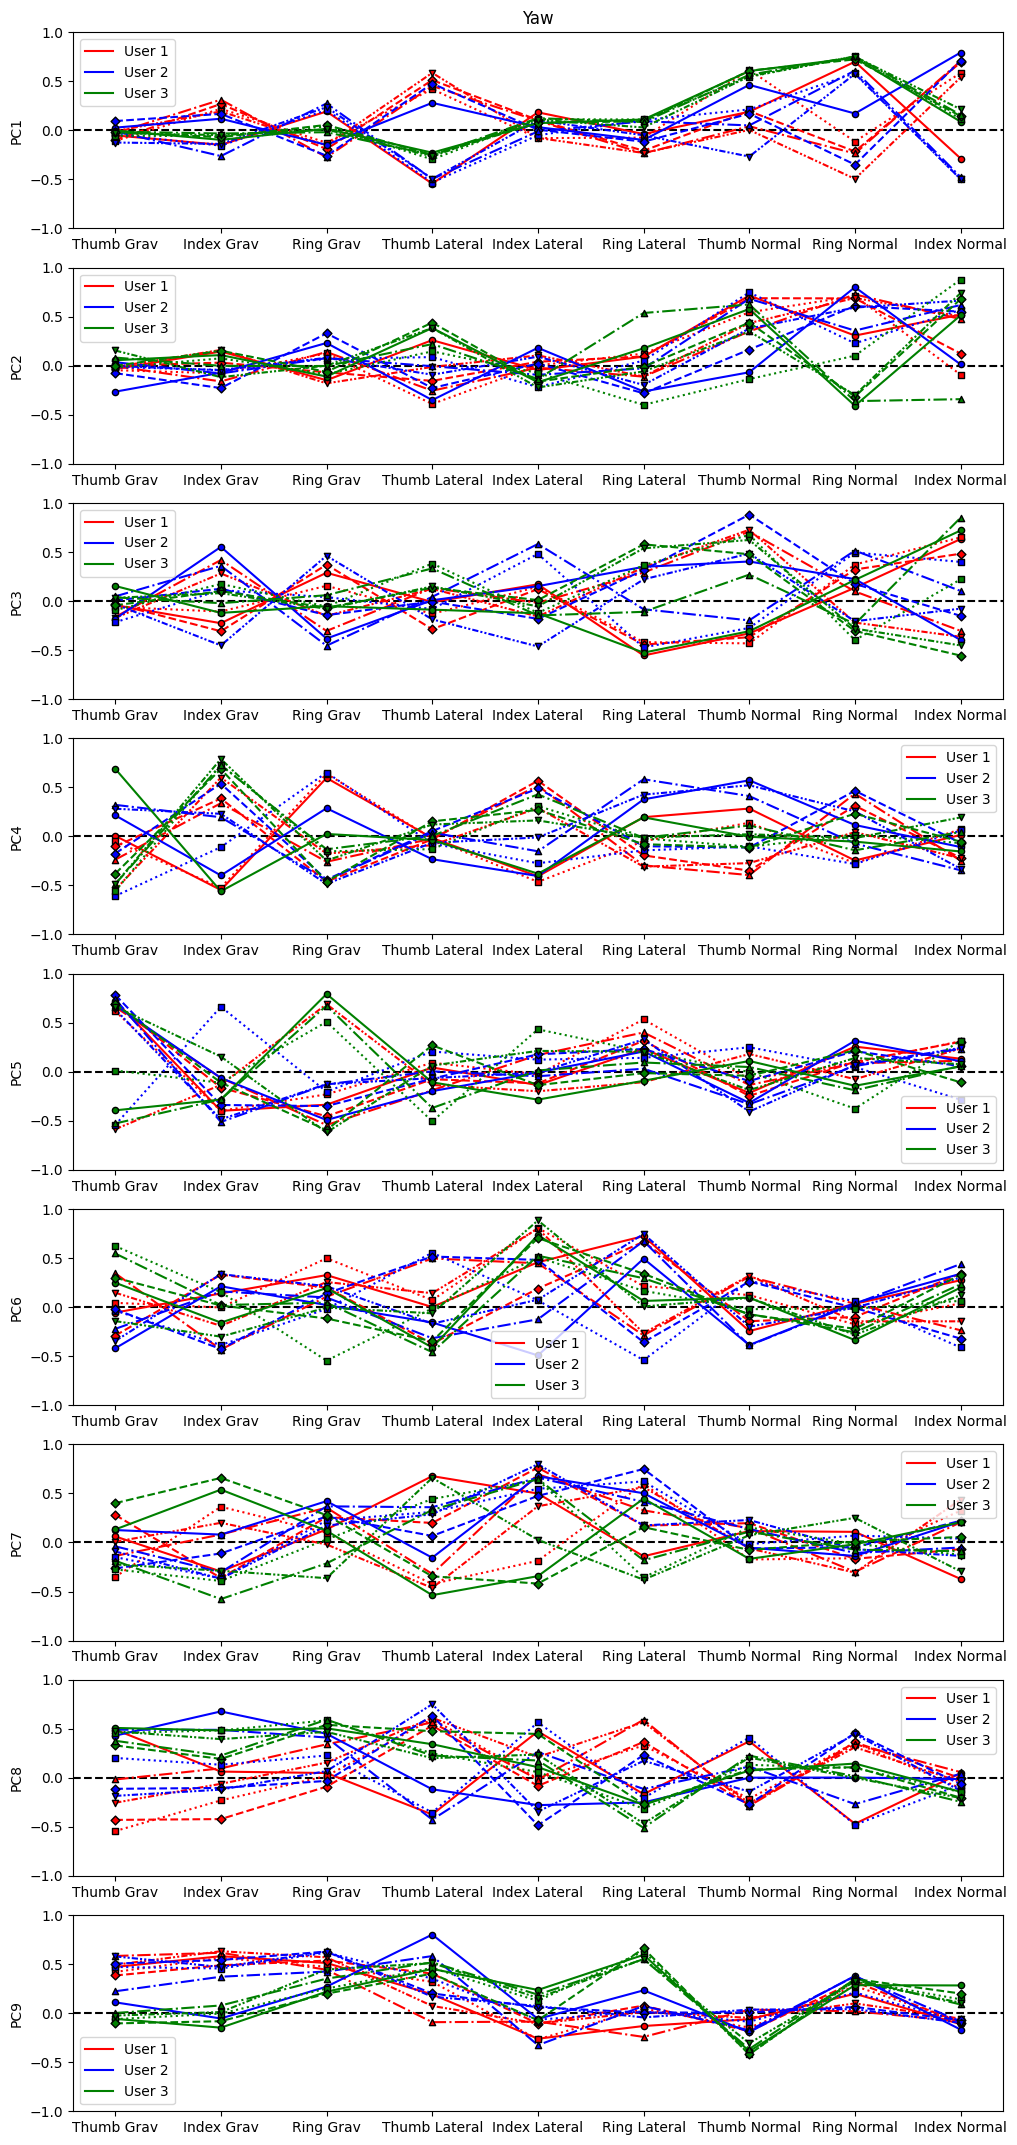

In [66]:
data_plotting(pca_dict)